# Softmax Function:

In [1]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Uses numerical stabilization.
    Input shape: (n_samples, n_classes)
    Output: probabilities where each row sums to 1.
    """
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Softmax Test case:
This test case checks that each row in the resulting softmax probabilities sums to 1, which is the fundamental property of softmax.


# Prediction Function

In [2]:
def predict_softmax(X, W, b):
    """
    Predict class labels using trained softmax model.
    Returns: array of shape (n_samples,) with class indices (0 to c-1)
    """
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

# Test Function for Prediction Function
The test function ensures that the predicted class labels have the same number of elements as the input samples, verifying that the model produces a valid output shape.


In [3]:
# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

# Predict
y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

# Print predictions
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


# Loss Function:

In [4]:
def loss_softmax(y_pred, y):
    """
    Compute the **average** cross-entropy loss over all samples.

    Parameters:
    y_pred : (n_samples, n_classes) predicted probabilities
    y      : (n_samples, n_classes) one-hot true labels

    Returns:
    float: mean cross-entropy loss
    """
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    per_sample_loss = -np.sum(y * np.log(y_pred), axis=1)
    return np.mean(per_sample_loss)

## Test case for Loss Function:
This test case Compares loss for correct vs. incorrect predictions.
*   Expects low loss for correct predictions.
*   Expects high loss for incorrect predictions.

In [5]:
import numpy as np

# Define correct predictions (low loss scenario)
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

y_pred_correct = np.array([
[0.9, 0.05, 0.05],
[0.1, 0.85, 0.05],
[0.05, 0.1, 0.85]
])

# Define incorrect predictions (high loss scenario)
y_pred_incorrect = np.array([
[0.05, 0.05, 0.9],
[0.1, 0.05, 0.85],
[0.85, 0.1, 0.05]
])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


# Cost Function

In [6]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return loss_softmax(y_pred, y)

### Test Case for Cost Function:
The test case assures that the cost for the incorrect prediction should be higher than for the correct prediction, confirming that the cost function behaves as expected.

In [7]:
# Example 1: Correct Prediction
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

# Example 2: Incorrect Prediction
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, f"Test failed: {cost_incorrect} <= {cost_correct}"

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


# Computing gradients:

In [8]:
import numpy as np

def softmax(z):
    """
    Compute softmax probabilities for a given input matrix z (n_samples x n_classes).
    """
    z_stable = z - np.max(z, axis=1, keepdims=True)  # numerical stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of softmax regression cost w.r.t weights and biases.

    Parameters:
    X: Feature matrix (n_samples x n_features)
    y: True labels, one-hot encoded (n_samples x n_classes)
    W: Weight matrix (n_features x n_classes)
    b: Bias vector (n_classes,)

    Returns:
    grad_W: Gradient w.r.t weights (n_features x n_classes)
    grad_b: Gradient w.r.t biases (n_classes,)
    """
    n_samples = X.shape[0]

    # Compute predicted probabilities
    z = np.dot(X, W) + b  # logits
    y_pred = softmax(z)

    # Gradient w.r.t weights
    grad_W = np.dot(X.T, (y_pred - y)) / n_samples

    # Gradient w.r.t biases
    grad_b = np.sum(y_pred - y, axis=0) / n_samples

    return grad_W, grad_b

### Test case for compute_gradient function:
The test checks if the gradients from the function are close enough to the manually computed gradients using np.allclose, which accounts for potential floating-point discrepancies.

In [9]:
# Test data
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

# Compute gradients using function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manual computation for verification
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

# Verify gradients
assert np.allclose(grad_W, grad_W_manual), "Gradient w.r.t. W mismatch"
assert np.allclose(grad_b, grad_b_manual), "Gradient w.r.t. b mismatch"

# Print results
print("Gradient w.r.t. W:\n", grad_W)
print("Gradient w.r.t. b:\n", grad_b)
print("Test passed!")

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b:
 [-0.03290036  0.02484708  0.00805328]
Test passed!


# Implementing Gradient Descent

In [10]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Compute current cost (required for history & plot!)
        z = np.dot(X, W) + b
        y_pred = softmax(z)
        cost = loss_softmax(y_pred, y)
        cost_history.append(cost)

        # Optional printing
        if show_cost and (i % max(1, n_iter // 10) == 0):
            print(f"Iteration {i+1}/{n_iter}, Cost: {cost:.6f}")

    return W, b, cost_history

# Preparing Dataset:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Softmax function
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Prediction function
def predict_softmax(X, W, b):
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

# Cross-entropy loss
def loss_softmax(y_pred, y_true):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# Compute gradients
def compute_gradient_softmax(X, y, W, b):
    n_samples = X.shape[0]
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)
    grad_W = np.dot(X.T, (y_pred - y)) / n_samples
    grad_b = np.sum(y_pred - y, axis=0) / n_samples
    return grad_W, grad_b

# Gradient descent
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        if show_cost and (i % max(1, n_iter // 10) == 0):
            logits = np.dot(X, W) + b
            y_pred = softmax(logits)
            cost = loss_softmax(y_pred, y)
            cost_history.append(cost)
            print(f"Iteration {i+1}/{n_iter}, Cost: {cost:.6f}")
    return W, b, cost_history

# Plot one sample per class
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
   

In [16]:
csv_file_path = "mnist_dataset.csv"  # Use forward slashes
print("Using file:", csv_file_path)

# Load the data directly
df = pd.read_csv(csv_file_path)
print("Data loaded successfully!")
print("Shape:", df.shape)


Using file: mnist_dataset.csv
Data loaded successfully!
Shape: (60000, 785)


In [17]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    # Load CSV
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values / 255.0  # Normalize

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file_path)

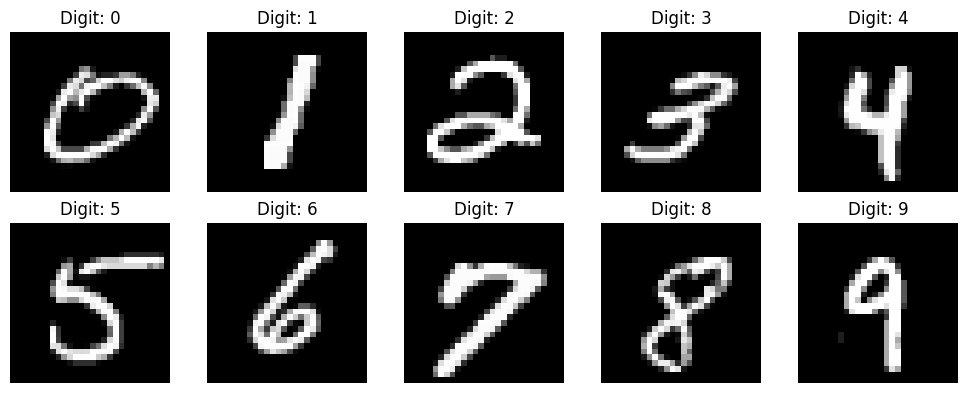

In [18]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # first occurrence
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call with train data
plot_sample_images(X_train, y_train)

# Question1:

No — extracting only raw pixel values is not sufficient for achieving the best possible performance in handwritten digit classification, although it is good enough to get reasonable results (~88–92% accuracy) with simple linear models like softmax regression.

Reasons why raw pixels are limited:


*   **Lack of invariance**: Raw pixels are extremely sensitive to small shifts, rotations, or scaling of the digit. Humans can recognize a "3" even if it's slightly rotated or moved, but a linear model sees completely different pixel patterns.
*   **High dimensionality and redundancy**: Each image has 784 features (28×28 pixels), many of which are highly correlated (neighboring pixels tend to have similar values). Linear models cannot effectively capture the spatial relationships.
*   **Limited discriminative power**: Many digits look similar in pixel space (e.g., 4 vs 9, 5 vs 3, 7 vs 1), so classes are not linearly separable in raw pixel space.
*   **Modern deep learning approach**: Convolutional Neural Networks (CNNs) automatically learn hierarchical features (edges → curves → digit parts) and achieve 98–99.7% accuracy on MNIST.

For teaching purposes and understanding how linear classifiers work, using raw pixels is perfectly appropriate and educational.  
However, for real-world high-accuracy digit recognition systems, more powerful feature extraction methods (especially CNNs) are necessary.

# **A Quick debugging Step:**

In [19]:
# Ensure feature and label arrays match
assert len(X_train) == len(y_train), f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


# Train The Model

In [20]:
# Print shapes
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (48000, 784)
Test data shape: (12000, 784)


Iteration 1/1000, Cost: 2.201590
Iteration 101/1000, Cost: 0.607540
Iteration 201/1000, Cost: 0.489453
Iteration 301/1000, Cost: 0.440770
Iteration 401/1000, Cost: 0.412678
Iteration 501/1000, Cost: 0.393817
Iteration 601/1000, Cost: 0.380006
Iteration 701/1000, Cost: 0.369310
Iteration 801/1000, Cost: 0.360697
Iteration 901/1000, Cost: 0.353557


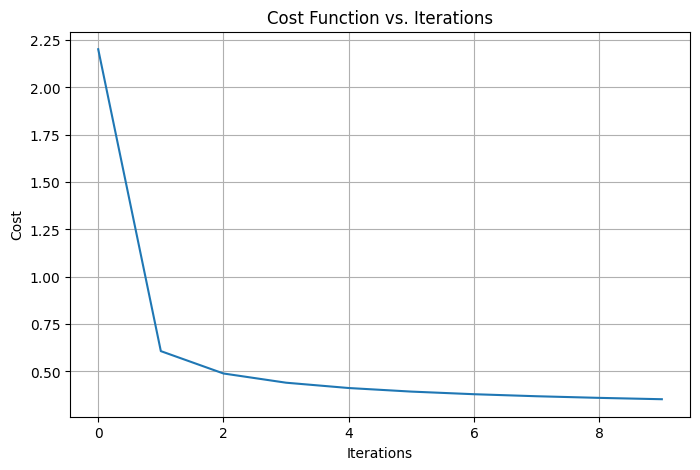

In [21]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# One-hot encode labels if not already encoded
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

# Dimensions
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes

# Initialize weights and biases
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)                    # Bias initialized to zero

# Hyperparameters
alpha = 0.1   # Learning rate
n_iter = 1000  # Number of iterations

# Train model
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# Evaluating the Model

In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.
    """
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Convert true labels back to numeric form
y_test_labels = np.argmax(y_test, axis=1)

# Calculate and print accuracy (only once)
accuracy = np.mean(y_pred_test == y_test_labels)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Test Accuracy: 0.9044 (90.44%)

Confusion Matrix:
[[1126    0    5    2    3   13    9    2   12    3]
 [   0 1275    7   11    1    5    1    4   17    1]
 [   1   16 1027   15   20    4   27   24   33    7]
 [   8    5   33 1050    1   53    9    8   31   21]
 [   1    5    7    1 1094    0   10    4    4   50]
 [  22   14   13   43   12  922   14    7   44   13]
 [   6    2    9    1   11   15 1121    2   10    0]
 [   7   27   24    4   16    2    0 1181    7   31]
 [   9   26   12   33    9   31   13    7 1005   15]
 [   8    6   10   18   43    9    0   38   10 1052]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


# Confusion Matrix in Visualize Form

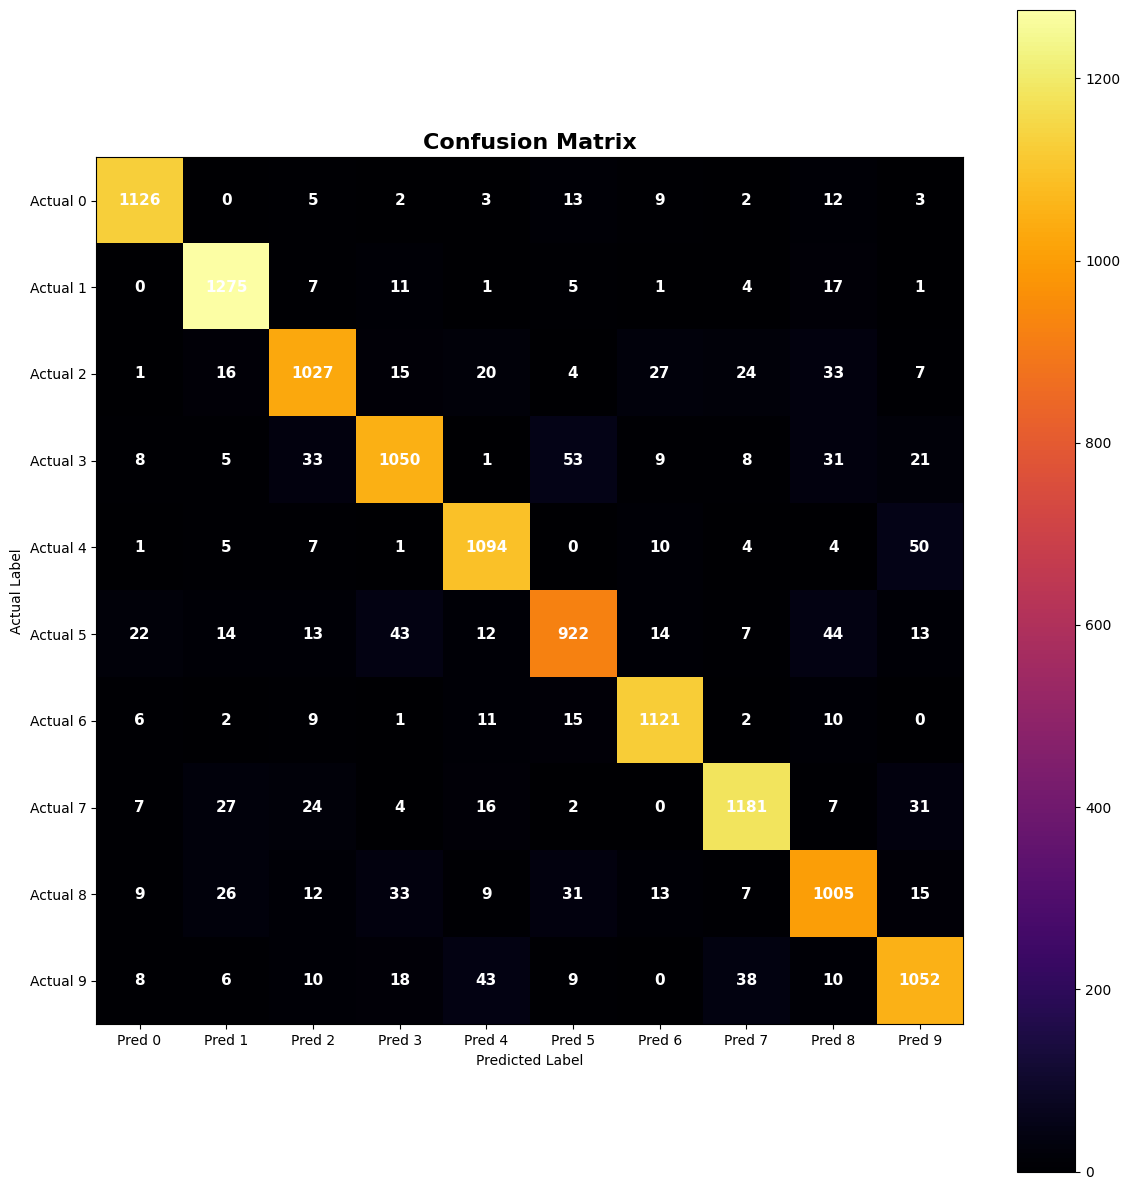

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 12))

# Dark background with bright highlights
cax = ax.imshow(cm, cmap='inferno')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

ax.set_xticklabels([f'Pred {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Always white text for visibility
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white',
                fontsize=11, fontweight='bold')

ax.grid(False)

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.colorbar(cax)
plt.tight_layout()
plt.show()

# Linear Seperability and Logistic Regression:

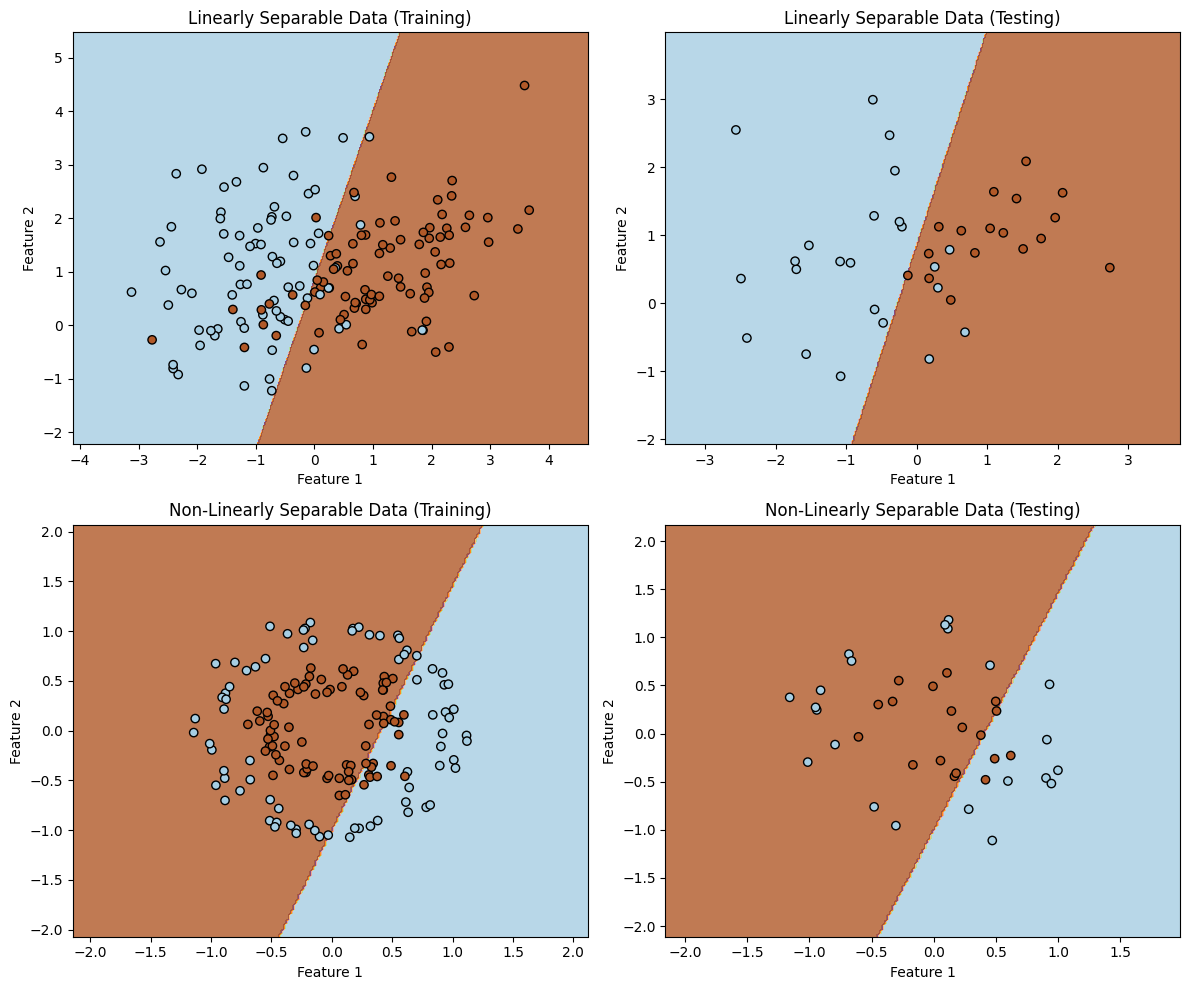

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(n_samples=200, n_features=2,
                                                             n_informative=2,
                                                             n_redundant=0, n_clusters_per_class=1,
                                                             random_state=42)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(n_samples=200, noise=0.1, factor=0.5,
                                                              random_state=42)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(axes[0, 0], logistic_model_linear_separable, X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable, X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable, X_train_non_linear,
                       y_train_non_linear, 'Non-Linearly Separable Data (Training)')

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable, X_test_non_linear,
                       y_test_non_linear, 'Non-Linearly Separable Data (Testing)')

plt.tight_layout()

# Save the plots as PNG files
plt.savefig('decision_boundaries.png')
plt.show()

# Question 2

**1. Linearly Separable Data**
*   Training & Testing: The logistic regression model successfully separates the two classes with a clear linear decision boundary.

**Observation:**
*  Most points from one class are on one side of the line, and points from the other class are on the opposite side.
*  This shows logistic regression performs well on linearly separable data because it assumes a linear relationship between features and the log-odds of the class probability.
---
**2. Non-Linearly Separable Data**
*   Training & Testing: The model fails to capture the circular pattern of the data.

**Observation:**
*  The decision boundary is still linear (straight line), so it misclassifies points that belong to the inner circle.
*  Logistic regression cannot separate non-linear patterns like concentric circles because it is inherently a linear classifier.
---
**Conclusion:**
*  Logistic regression works well for linearly separable data but struggles with non-linear datasets.
*  For non-linear problems, one would need to use a model capable of capturing non-linear decision boundaries, such as kernelized SVMs, decision trees, random forests, or neural networks.

# Question 3

While implementing the code, I faced a few challenges:

*   At first, the decision boundary looked rough because of the meshgrid step size. I changed the value to make it smoother, but it slightly increased the execution time.
*   Some errors occurred due to incorrect quotation marks when copying the code, which I had to fix manually.
*   I found it difficult to understand why logistic regression did not work well on the circles dataset. Later, I understood that it is because the data is non-linear, and logistic regression can only create a straight-line boundary.
*   There were minor issues with plot alignment, which I fixed using layout adjustments.
*   Overall, this helped me understand both the working and limitations of the model more clearly.
